In [34]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
import seaborn as sns

## Load Data

In [8]:
df = pd.read_csv("housing.csv")

###  Describe the Data

In [11]:
df.head() # What is in the data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
df.describe() # Describing the numeric data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
df.isnull().sum() # Identifying missing variables

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


### Fill in missing values

In [13]:
# 1. Fill missing values on the RAW data first

median_total_bedrooms = df['total_bedrooms'].median()

df['total_bedrooms'] = df['total_bedrooms'].fillna(median_total_bedrooms)


# Check the missing values again

df.isna().sum()
# 1. Handle Missing Values globally on the RAW data first


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


#### Check for outliers in the data using BoxPlots

<Axes: >

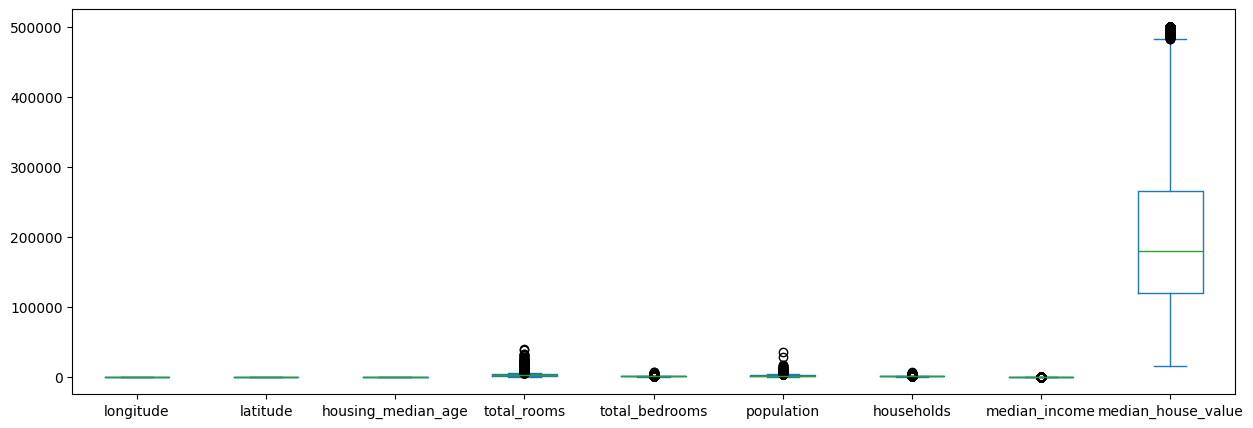

In [16]:
df.plot(kind='box', figsize=(15,5))

,0
longitude,"Axes(0.125,0.11;0.0731132x0.77)"
latitude,"Axes(0.212736,0.11;0.0731132x0.77)"
housing_median_age,"Axes(0.300472,0.11;0.0731132x0.77)"
total_rooms,"Axes(0.388208,0.11;0.0731132x0.77)"
total_bedrooms,"Axes(0.475943,0.11;0.0731132x0.77)"
population,"Axes(0.563679,0.11;0.0731132x0.77)"
households,"Axes(0.651415,0.11;0.0731132x0.77)"
median_income,"Axes(0.739151,0.11;0.0731132x0.77)"
median_house_value,"Axes(0.826887,0.11;0.0731132x0.77)"


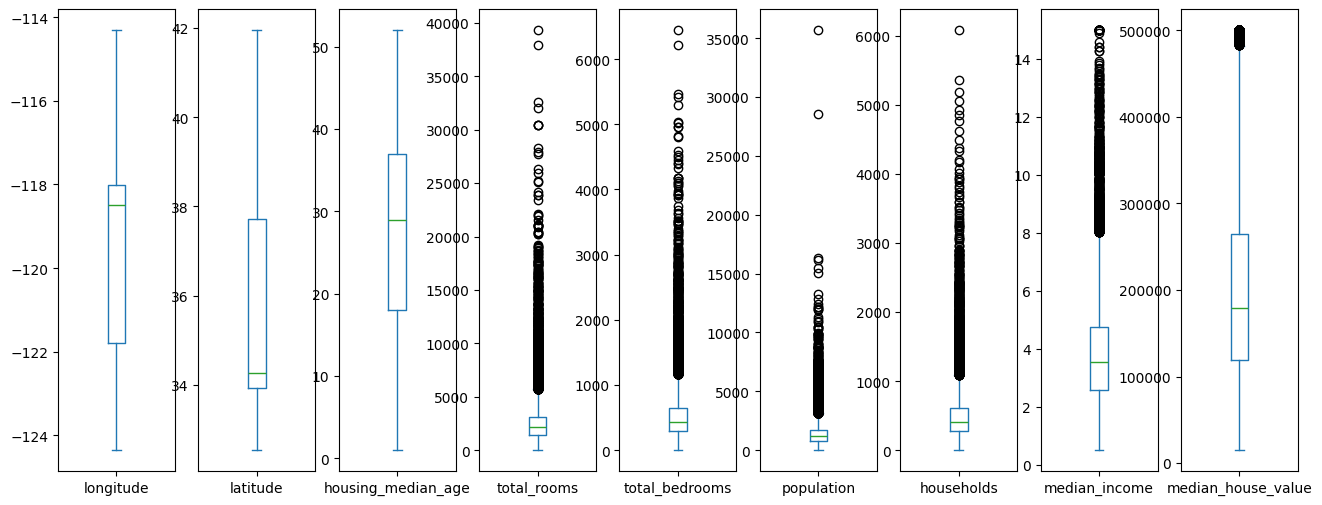

In [15]:
df.plot(kind='box', subplots=True, figsize=(16,6))

##### Get the Numeric Data only

In [20]:
df_numeric = df.drop(columns='ocean_proximity')

 #### Check for skewness

In [21]:
print(df_numeric.skew().sort_values(ascending=True))

longitude            -0.297801
housing_median_age    0.060331
latitude              0.465953
median_house_value    0.977763
median_income         1.646657
households            3.410438
total_bedrooms        3.481141
total_rooms           4.147343
population            4.935858
dtype: float64


#### Confirm the 500K capped in median house value

<Axes: xlabel='median_house_value', ylabel='median_income'>

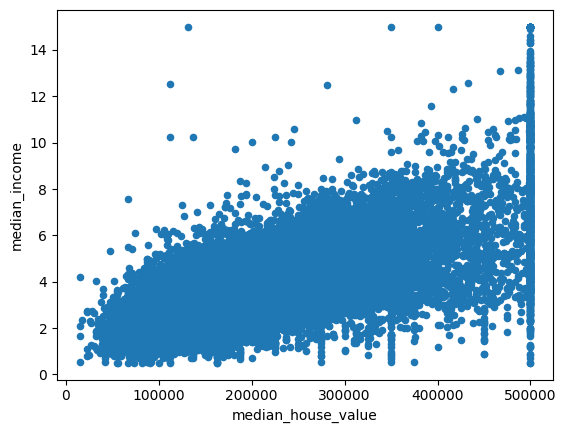

In [23]:
df_numeric.plot(kind='scatter', x = 'median_house_value', y = 'median_income')

##### Remove the cap on median_house_value

In [24]:
df_numeric = df_numeric[df_numeric['median_house_value'] < 500000]

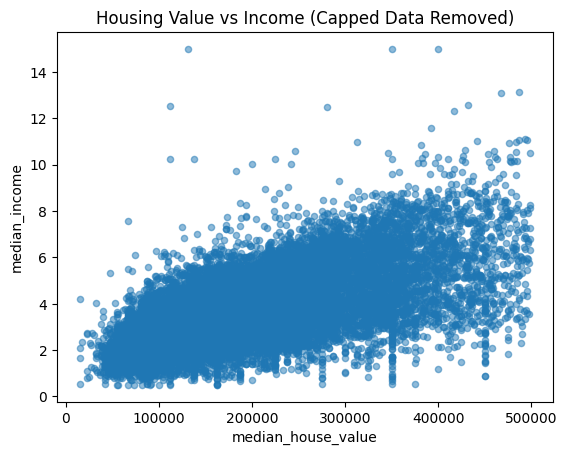

In [26]:
### The Plot
df_numeric.plot(kind='scatter', x = 'median_house_value', y = 'median_income', alpha=0.5)
plt.title("Housing Value vs Income (Capped Data Removed)")
plt.show()

In [28]:
print(df_numeric.skew().sort_values(ascending=True))

longitude            -0.291162
housing_median_age    0.069155
latitude              0.456871
median_house_value    0.795231
median_income         0.913820
households            3.409187
total_bedrooms        3.480589
total_rooms           4.226300
population            4.961355
dtype: float64


### Introduce Yeo-Johnson and np.sqrt transformation

In [31]:
# 2. Create the log-transformed columns on the RAW data
columns_to_transform = ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'median_house_value']
columns_to_keep = ['longitude', 'latitude', 'housing_median_age']

# Yeo-Johnson

yj_init = PowerTransformer(method='yeo-johnson')
yj_array = yj_init.fit_transform(df_numeric[columns_to_transform])

yj_dataframe = pd.DataFrame(yj_array, columns=columns_to_transform)


# Square Root transformation
sqrt_dataframe = np.sqrt(df_numeric[columns_to_transform])


### Check the skewness of each dataframe side by side in a table form

In [33]:
# 1. Calculate the skewness series for each dataframe configuration
raw_skew = df_numeric[columns_to_transform].skew()
sqrt_skew = sqrt_dataframe.skew()
yj_skew = yj_dataframe.skew()


# 2. Combine the series into a single summary DataFrame
skew_comparison_df = pd.DataFrame({
    'Raw Skewness': raw_skew,
    'Square Root Skewness': sqrt_skew,
    'Yeo-Johnson Skewness': yj_skew
})


# 3. Sort by the severity of the original raw skewness for clearer reading
skew_comparison_df = skew_comparison_df.sort_values(by='Raw Skewness', ascending=False)

# 4. Display the results directly as a clean Markdown table for your notebook/README
print("### 📊 Distribution Skewness Side-by-Side Comparison")
print(skew_comparison_df.round(4).to_markdown())

### 📊 Distribution Skewness Side-by-Side Comparison
|                    |   Raw Skewness |   Square Root Skewness |   Yeo-Johnson Skewness |
|:-------------------|---------------:|-----------------------:|-----------------------:|
| population         |         4.9614 |                 1.2313 |                 0.1112 |
| total_rooms        |         4.2263 |                 1.3833 |                 0.1201 |
| total_bedrooms     |         3.4806 |                 1.2286 |                 0.107  |
| households         |         3.4092 |                 1.137  |                 0.1089 |
| median_income      |         0.9138 |                 0.278  |                -0.0009 |
| median_house_value |         0.7952 |                 0.2729 |                -0.0232 |


### The Plot side by side

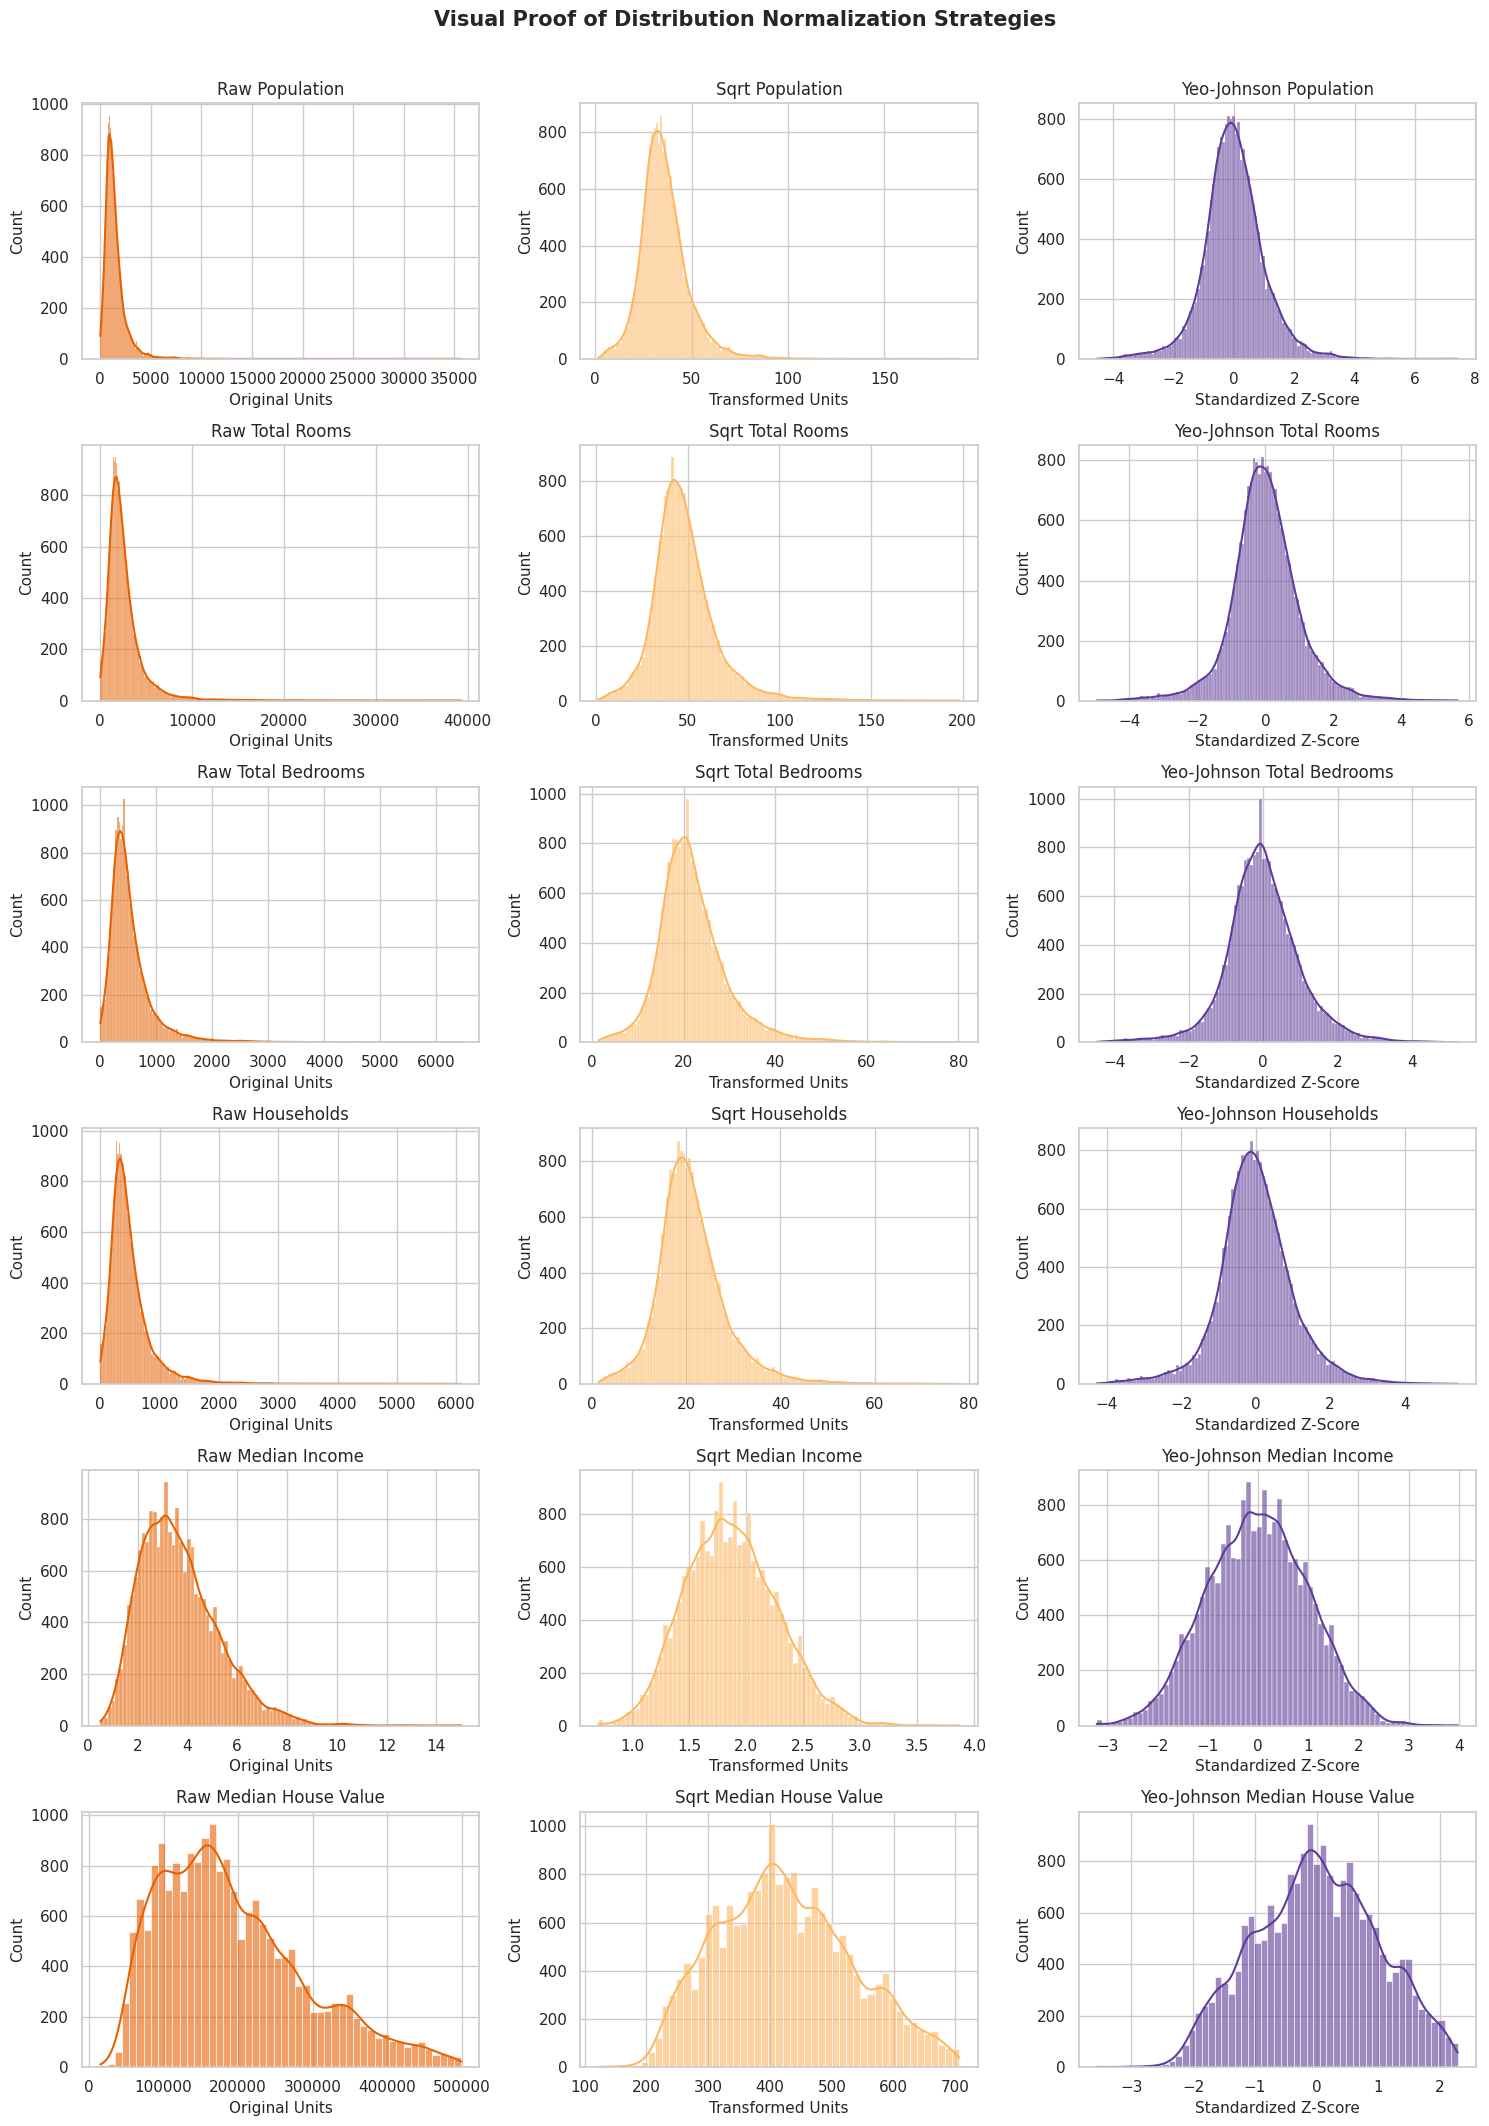

In [35]:

# Set a clean, modern aesthetic for your GitHub repository and blog post
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.titlesize': 15
})

# Columns matching your clean skewness dataframe exactly
columns_to_plot = ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'median_house_value']

# Set up the 3-column grid structure (Rows = Features, Cols = Raw, Sqrt, YJ)
fig, axes = plt.subplots(nrows=len(columns_to_plot), ncols=3, figsize=(15, 3.5 * len(columns_to_plot)))
fig.suptitle("Visual Proof of Distribution Normalization Strategies", fontweight='bold', y=1.01)

for i, col in enumerate(columns_to_plot):
    # Column 1: Raw Data (Heavy Right Skew / Long Tails)
    sns.histplot(df_numeric[col], kde=True, ax=axes[i, 0], color='#e66101', alpha=0.6)
    axes[i, 0].set_title(f"Raw {col.replace('_', ' ').title()}")
    axes[i, 0].set_xlabel("Original Units")

    # Column 2: Square Root Data (Partial Under-Correction)
    sns.histplot(sqrt_dataframe[col], kde=True, ax=axes[i, 1], color='#fdb863', alpha=0.6)
    axes[i, 1].set_title(f"Sqrt {col.replace('_', ' ').title()}")
    axes[i, 1].set_xlabel("Transformed Units")

    # Column 3: Yeo-Johnson Data (Symmetrical Bell Curves)
    sns.histplot(yj_dataframe[col], kde=True, ax=axes[i, 2], color='#5e3c99', alpha=0.6)
    axes[i, 2].set_title(f"Yeo-Johnson {col.replace('_', ' ').title()}")
    axes[i, 2].set_xlabel("Standardized Z-Score")

# Optimize spacing to eliminate text overlapping or clipping
plt.tight_layout()

# Save as a premium visualization asset for your workspace
plt.savefig("transformation_comparison_proof.png", dpi=300, bbox_inches='tight')
plt.show()


## End of  feature engineering visualization

### Modeling and Training on Data

In [37]:
print(df_numeric.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

# 1. HARD RESET: Filter the $500k cap from your verified raw columns list
df_pipeline = df_numeric[df_numeric['median_house_value'] < 500000].copy()

# 2. SEPARATE FEATURES AND TARGET Securely
features_list = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
X = df_pipeline[features_list].copy()
y = df_pipeline['median_house_value'].copy()

# 3. SPLIT AND DECOUPLE COPIES
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

# 4. LEAK-PROOF IMPUTATION (Guaranteed to execute)
train_median_bedrooms = X_train['total_bedrooms'].median()
X_train['total_bedrooms'] = X_train['total_bedrooms'].fillna(train_median_bedrooms)
X_test['total_bedrooms'] = X_test['total_bedrooms'].fillna(train_median_bedrooms)

# =====================================================================
# 5. PIPELINE TRANSFORMATIONS
# =====================================================================
columns_to_transform = ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income']
columns_to_keep = ['longitude', 'latitude', 'housing_median_age']

yj_pipeline = PowerTransformer(method='yeo-johnson')

# Process Training Split
X_train_trans = yj_pipeline.fit_transform(X_train[columns_to_transform])
X_train_clean = pd.DataFrame(X_train_trans, columns=columns_to_transform, index=X_train.index)

# Process Testing Split
X_test_trans = yj_pipeline.transform(X_test[columns_to_transform])
X_test_clean = pd.DataFrame(X_test_trans, columns=columns_to_transform, index=X_test.index)

# Merge Isolated Spatial/Temporal Markers
for col in columns_to_keep:
    X_train_clean[col] = X_train[col]
    X_test_clean[col] = X_test[col]

print("🚀 Pipeline executed perfectly with absolute data symmetry!")
print(f"X_train_clean columns: {X_train_clean.columns.tolist()}")
print(f"X_test_clean columns: {X_test_clean.columns.tolist()}")


🚀 Pipeline executed perfectly with absolute data symmetry!
X_train_clean columns: ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'longitude', 'latitude', 'housing_median_age']
X_test_clean columns: ['population', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'longitude', 'latitude', 'housing_median_age']


### Baseline and Optminal Model

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# =====================================================================
# 1. BASELINE MODEL: LINEAR REGRESSION
# =====================================================================
lr_model = LinearRegression()
lr_model.fit(X_train_clean, y_train)
lr_preds = lr_model.predict(X_test_clean)


In [41]:
# =====================================================================
# 2. CHALLENGER MODEL: RANDOM FOREST
# =====================================================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_clean, y_train)
rf_preds = rf_model.predict(X_test_clean)


In [42]:

# =====================================================================
# 3. PRINT EVALUATION SCORECARD
# =====================================================================
print("=========================================")
print("          🏆 FINAL MODEL SCORECARD        ")
print("=========================================")
print("Linear Regression (Baseline):")
print(f"  • Test RMSE : ${root_mean_squared_error(y_test, lr_preds):,.2f}")
print(f"  • Test R²   : {r2_score(y_test, lr_preds):.4f}")
print("-" * 41)
print("Random Forest Regressor (Challenger):")
print(f"  • Test RMSE : ${root_mean_squared_error(y_test, rf_preds):,.2f}")
print(f"  • Test R²   : {r2_score(y_test, rf_preds):.4f}")
print("=========================================")

          🏆 FINAL MODEL SCORECARD        
Linear Regression (Baseline):
  • Test RMSE : $62,494.46
  • Test R²   : 0.5926
-----------------------------------------
Random Forest Regressor (Challenger):
  • Test RMSE : $45,726.66
  • Test R²   : 0.7819


### Which variable is or are strong predictors?

In [43]:
# 1. Combine the training features and training target into a single temporary matrix
train_correlation_matrix = X_train.copy()
train_correlation_matrix['median_house_value'] = y_train

# 2. Compute the Pearson correlation coefficients
correlations = train_correlation_matrix.corr()['median_house_value'].sort_values(ascending=False)

# 3. Print out your official feature importance table
print("==================================================")
print(" 🔍 RAW TRAINING DATA CORRELATIONS WITH TARGET   ")
print("==================================================")
print(correlations.to_string(float_format="{:.4f}".format))
print("==================================================")


 🔍 RAW TRAINING DATA CORRELATIONS WITH TARGET   
median_house_value    1.0000
median_income         0.6482
total_rooms           0.1439
households            0.0937
total_bedrooms        0.0727
housing_median_age    0.0644
population            0.0123
longitude            -0.0450
latitude             -0.1504


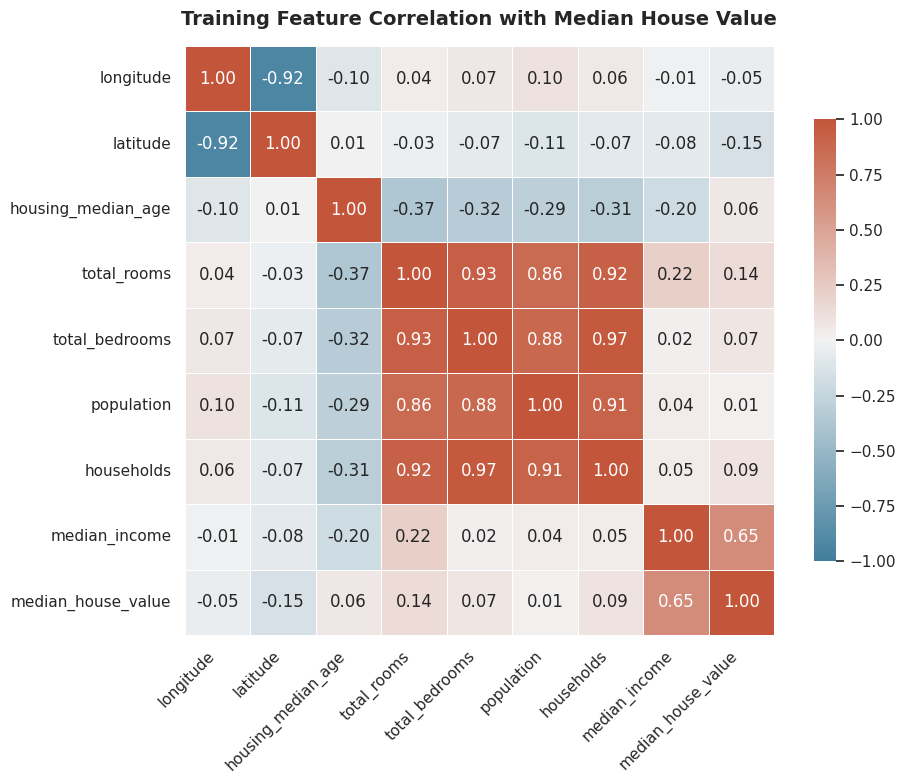

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recreate your clean training correlation dataframe
train_correlation_matrix = X_train.copy()
train_correlation_matrix['median_house_value'] = y_train

# Compute the full pairwise Pearson correlation matrix
corr_matrix = train_correlation_matrix.corr()

# 2. Set up a clean, modern style for GitHub and Medium
sns.set_theme(style="white")
plt.figure(figsize=(10, 8))

# Create a custom divergent color palette (warm colors for positive, cool for negative)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# 3. Draw the heatmap with annotations and clean formatting
sns.heatmap(
    corr_matrix,
    annot=True,             # Write the actual correlation numbers inside the squares
    fmt=".2f",              # Round numbers to 2 decimal places
    cmap=cmap,              # Apply our premium color palette
    vmax=1.0, vmin=-1.0,    # Fix the scale boundaries to standard correlation limits
    center=0,               # Center the color scale right at 0
    square=True,            # Make all cells perfectly square
    linewidths=.5,          # Add a subtle grid line between cells
    cbar_kws={"shrink": .75} # Make the color bar scale fit cleanly next to the plot
)

# 4. Add clear titles and labels
plt.title("Training Feature Correlation with Median House Value", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right') # Tilt labels so they don't overlap
plt.yticks(rotation=0)

# Adjust layout and save directly as a PNG for your project
plt.tight_layout()
plt.savefig("train_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
